Seasonal Agriculture Performance Analysis

VOIS AICTE Batch1 2026-2027 Major Project

Objective:
To analyze agricultural performance across different seasons and identify meaningful patterns, trends, relationships and variations using data analytics techniques.



Problem Statement:

Agricultural performance varies across seasons due to environmental conditions, resource usage, and farming practices.

This project analyzes seasonal agricultural data to identify patterns, trends, relationships, and differences in agricultural performance.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway

plt.style.use('default')

In [2]:
from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv


In [3]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (4000, 28)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [6]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [7]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [8]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

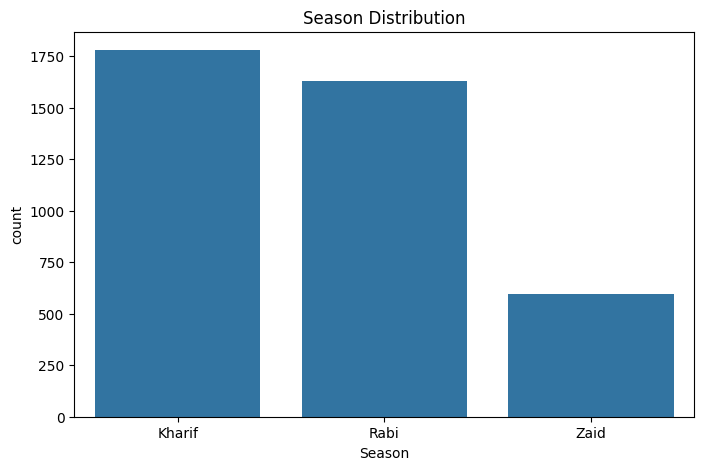

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Season',
    data=df
)

plt.title('Season Distribution')
plt.show()

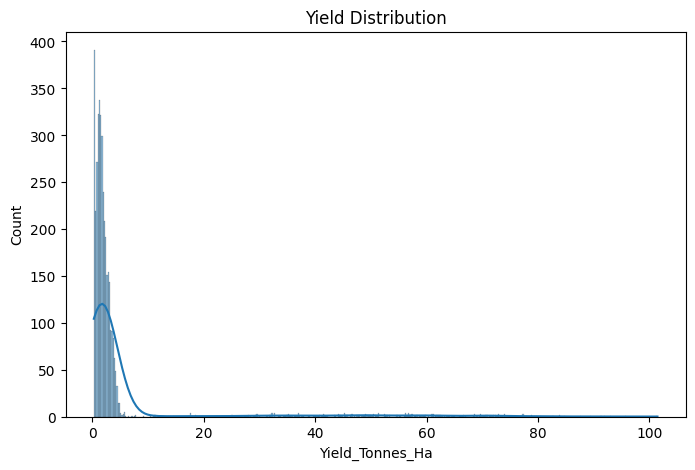

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Yield_Tonnes_Ha'],
    kde=True
)

plt.title('Yield Distribution')
plt.show()

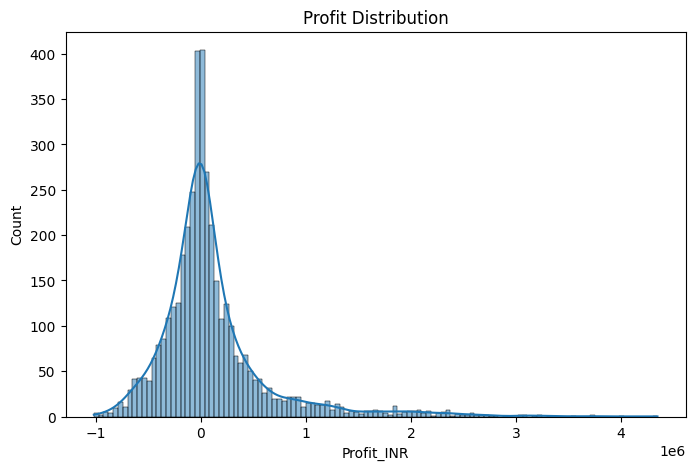

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Profit_INR'],
    kde=True
)

plt.title('Profit Distribution')
plt.show()

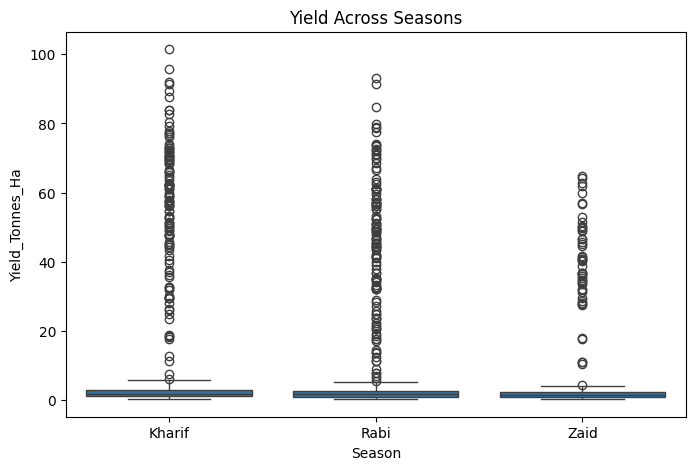

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Season',
    y='Yield_Tonnes_Ha',
    data=df
)

plt.title('Yield Across Seasons')
plt.show()

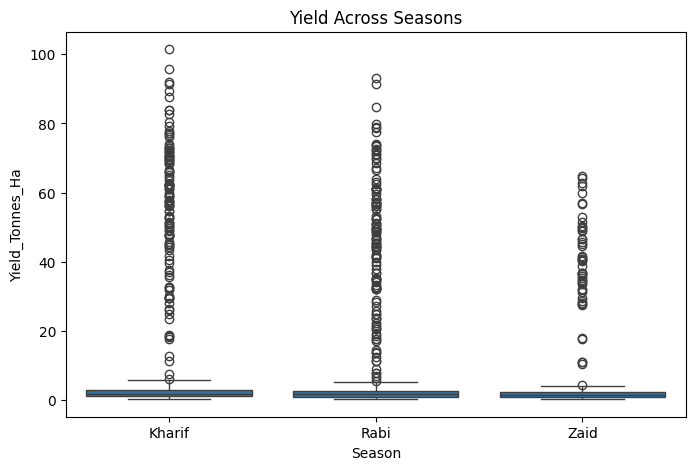

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Season',
    y='Yield_Tonnes_Ha',
    data=df
)

plt.title('Yield Across Seasons')
plt.show()

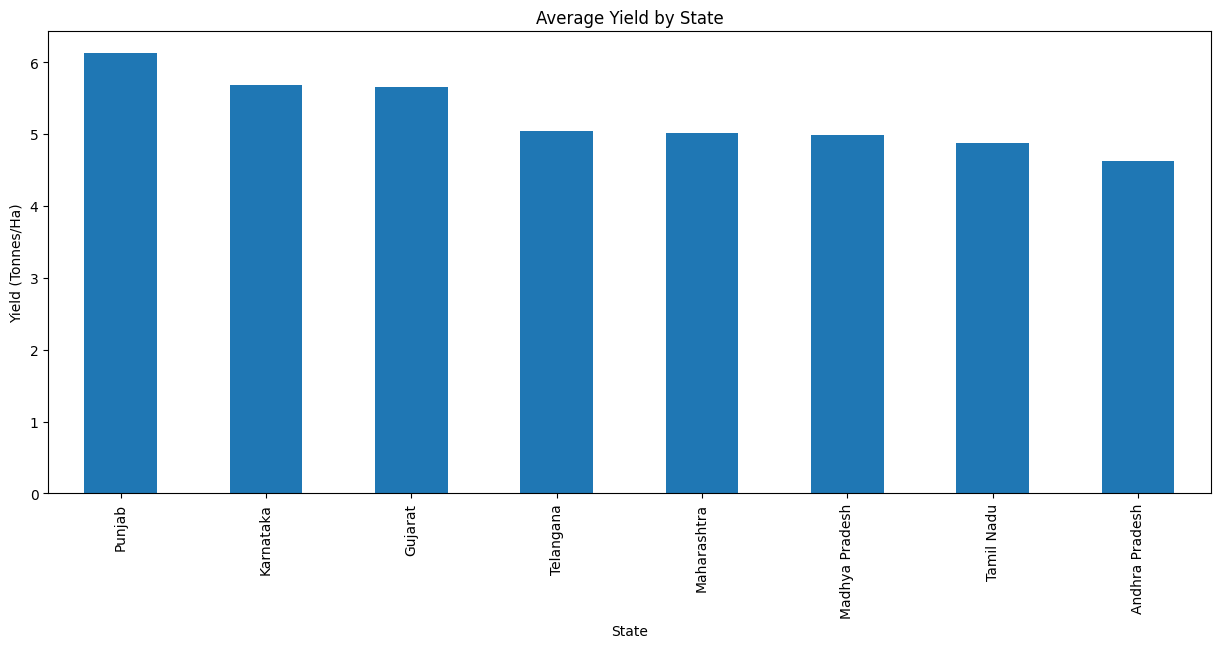

In [32]:
plt.figure(figsize=(15,6))

state_yield = df.groupby('State')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

state_yield.plot(kind='bar')

plt.title("Average Yield by State")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

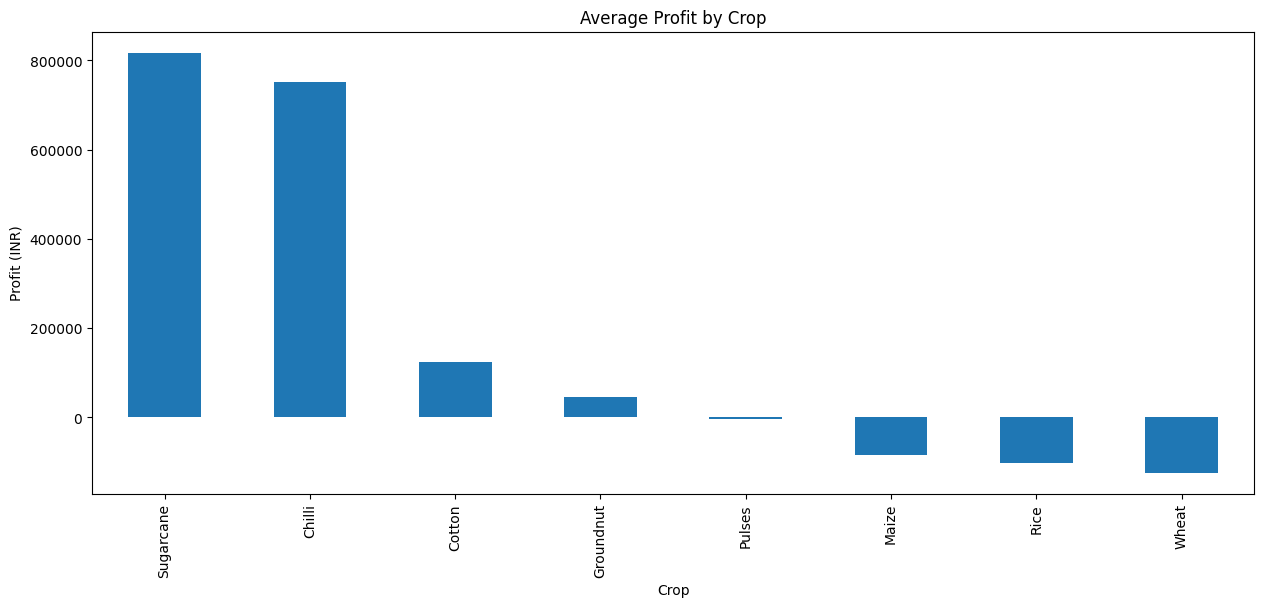

In [33]:
plt.figure(figsize=(15,6))

crop_profit = df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False)

crop_profit.plot(kind='bar')

plt.title("Average Profit by Crop")
plt.ylabel("Profit (INR)")
plt.show()

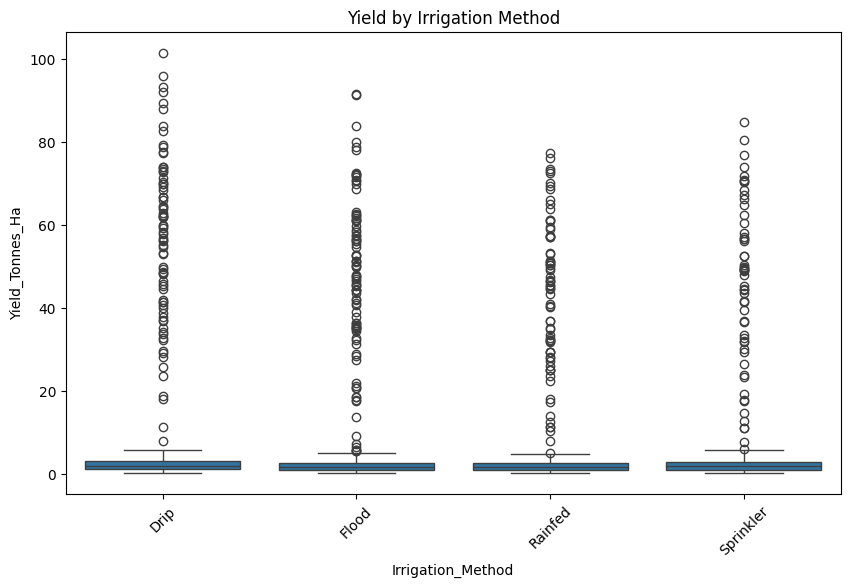

In [34]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Irrigation_Method',
    y='Yield_Tonnes_Ha',
    data=df
)

plt.title("Yield by Irrigation Method")
plt.xticks(rotation=45)

plt.show()

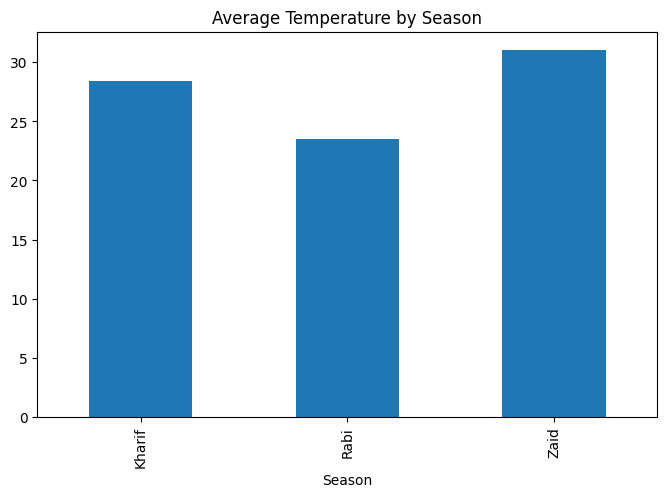

In [17]:
df.groupby('Season')['Avg_Temperature_C'].mean().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average Temperature by Season')
plt.show()

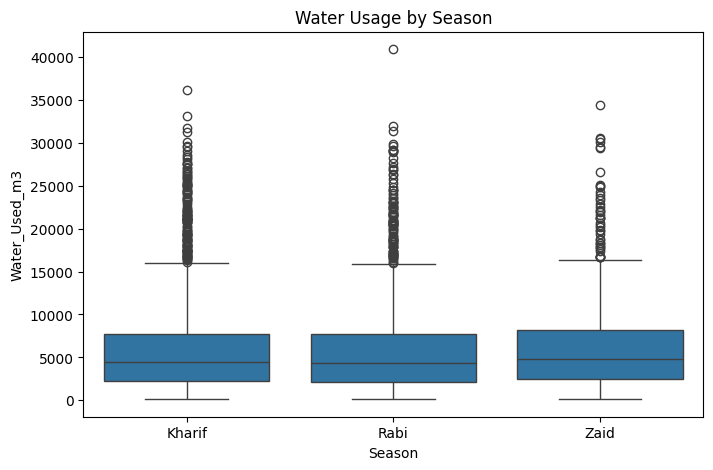

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Season',
    y='Water_Used_m3',
    data=df
)

plt.title('Water Usage by Season')
plt.show()

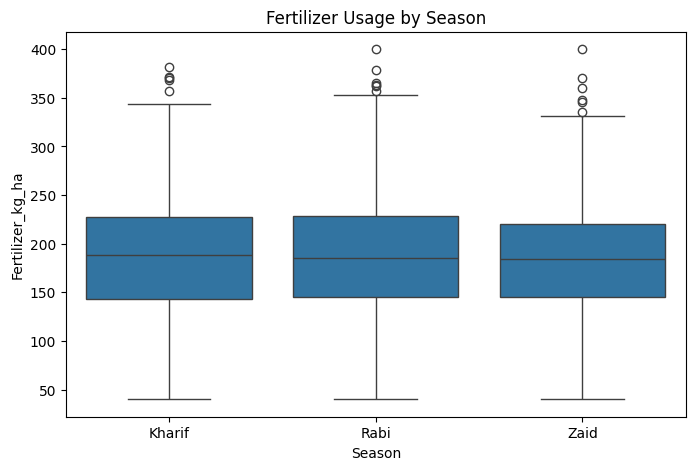

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Season',
    y='Fertilizer_kg_ha',
    data=df
)

plt.title('Fertilizer Usage by Season')
plt.show()

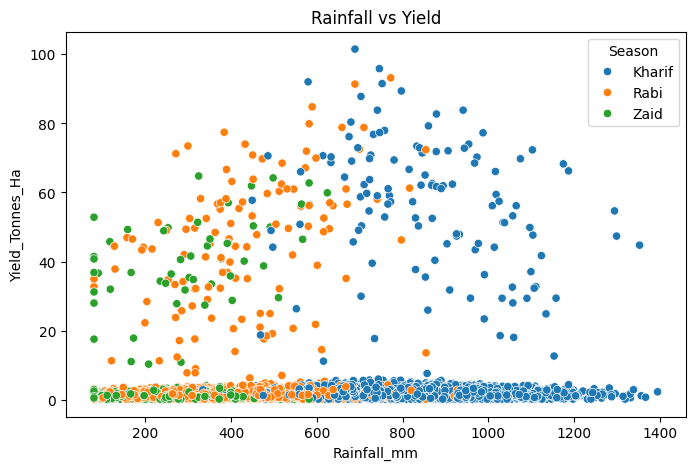

In [20]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season',
    data=df
)

plt.title('Rainfall vs Yield')
plt.show()

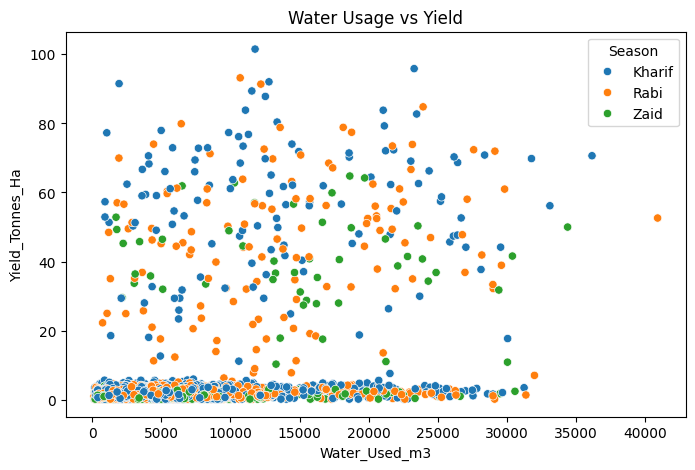

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Water_Used_m3',
    y='Yield_Tonnes_Ha',
    hue='Season',
    data=df
)

plt.title('Water Usage vs Yield')
plt.show()

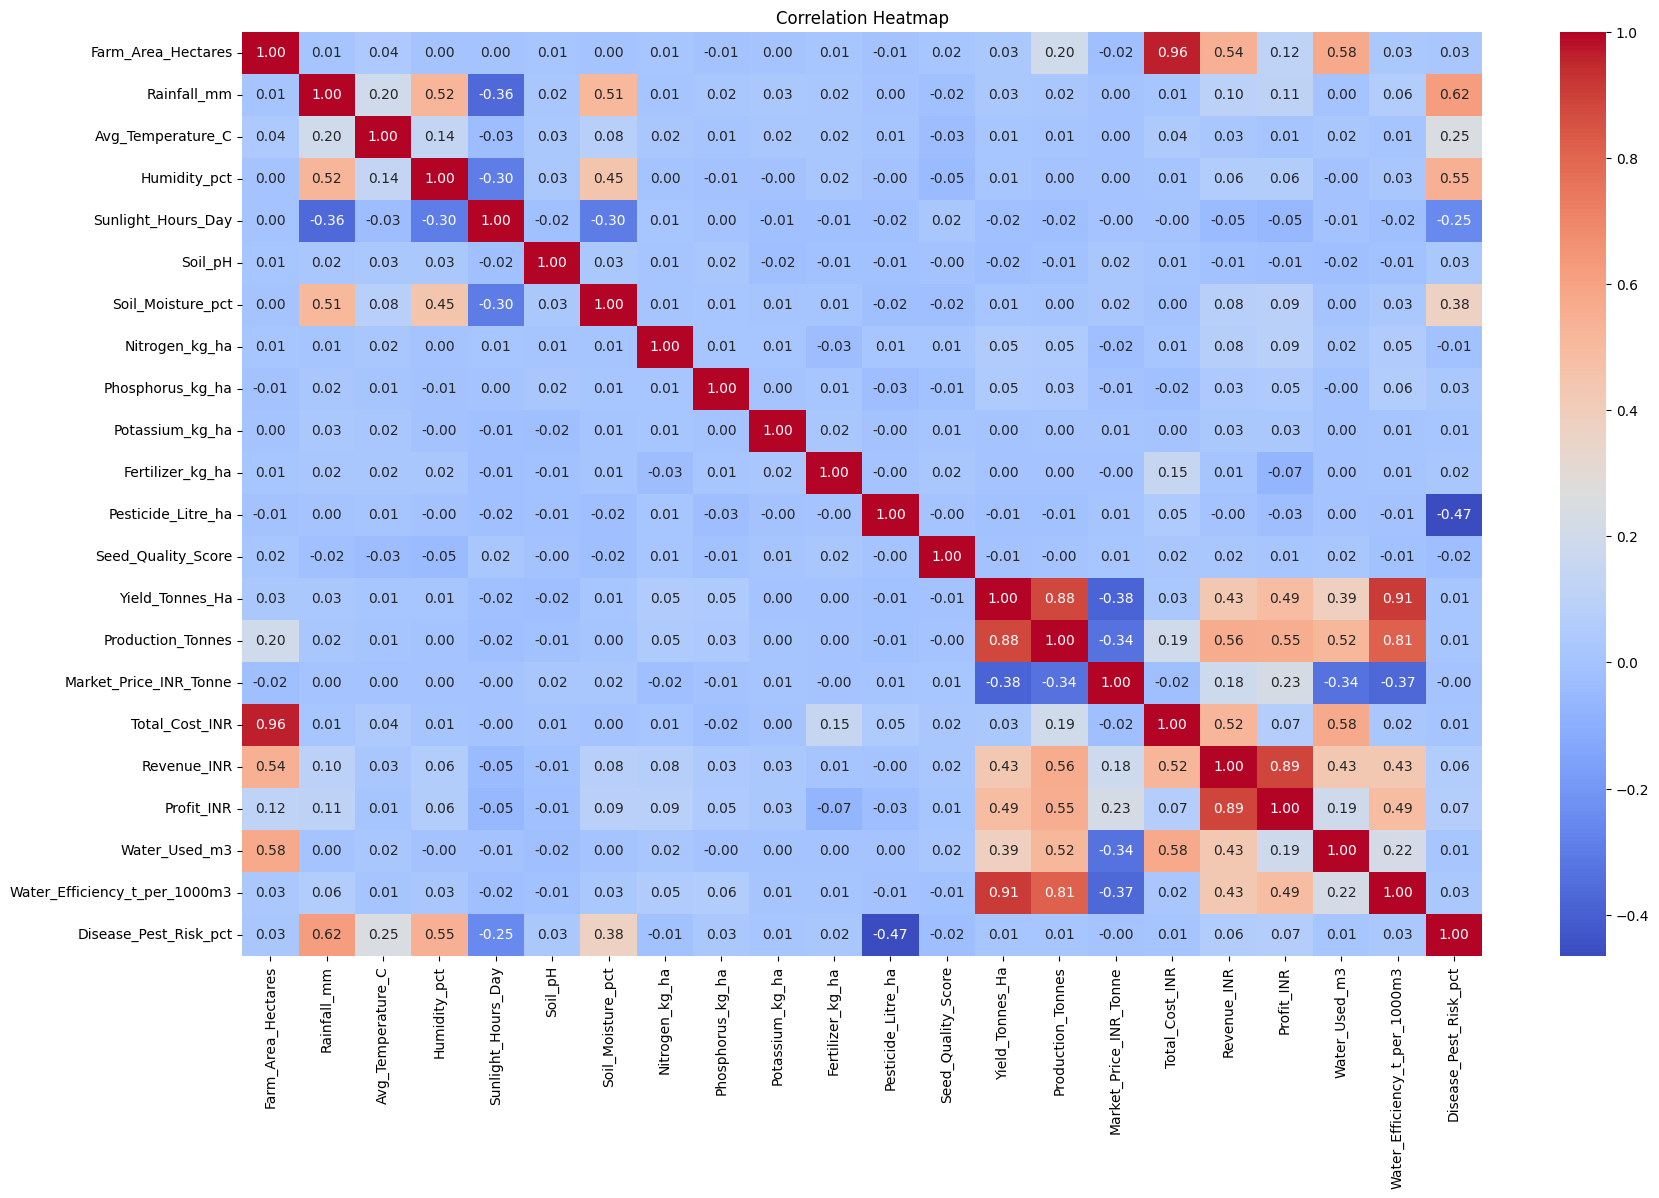

In [22]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(20,12))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

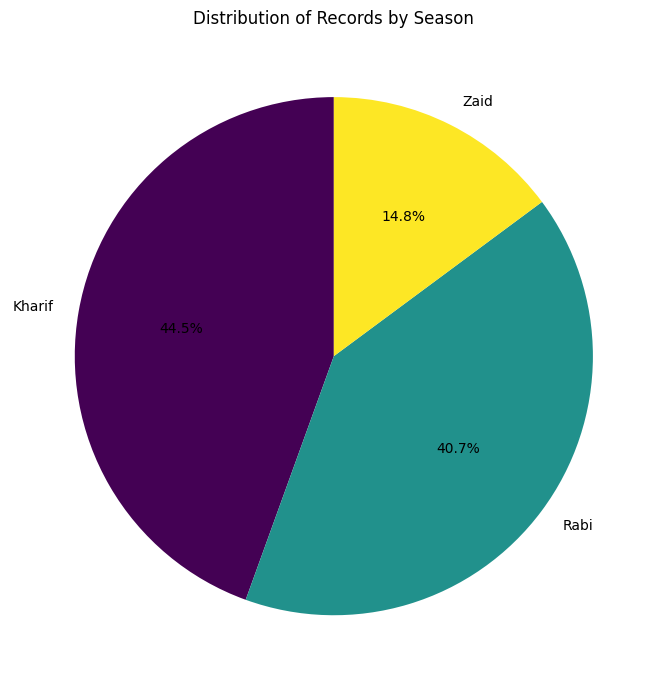

In [36]:

plt.figure(figsize=(7, 7))
df['Season'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')
plt.title('Distribution of Records by Season')
plt.ylabel('') # Hide the default 'Season' label on the y-axis
plt.tight_layout()
plt.show()

In [35]:
kharif = df[df['Season']=='Kharif']['Yield_Tonnes_Ha']
rabi = df[df['Season']=='Rabi']['Yield_Tonnes_Ha']
zaid = df[df['Season']=='Zaid']['Yield_Tonnes_Ha']

f,p = f_oneway(
    kharif,
    rabi,
    zaid
)

print("F-statistic:", f)
print("P-value:", p)

F-statistic: 1.5438804542488311
P-value: 0.21367813841792296


In [24]:
if p < 0.05:
    print("Significant difference between seasons")
else:
    print("No significant difference between seasons")

No significant difference between seasons


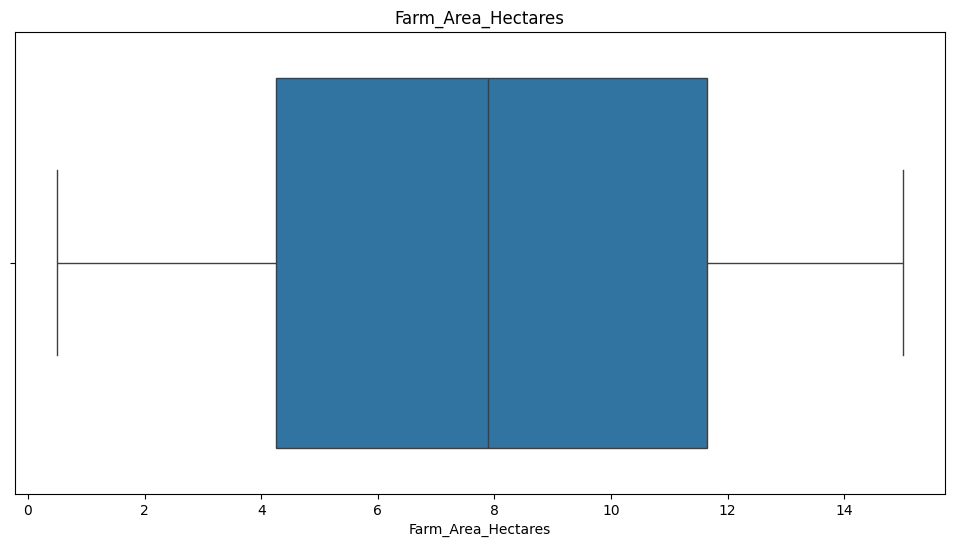

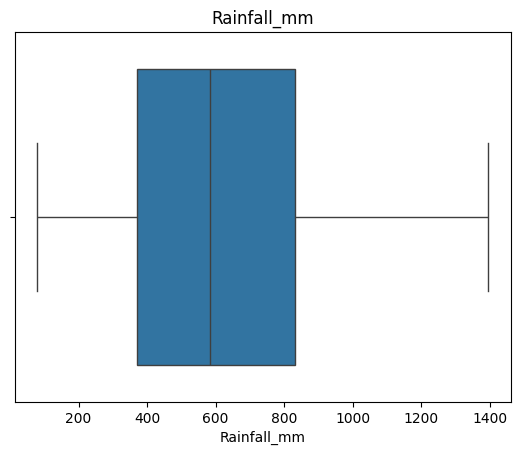

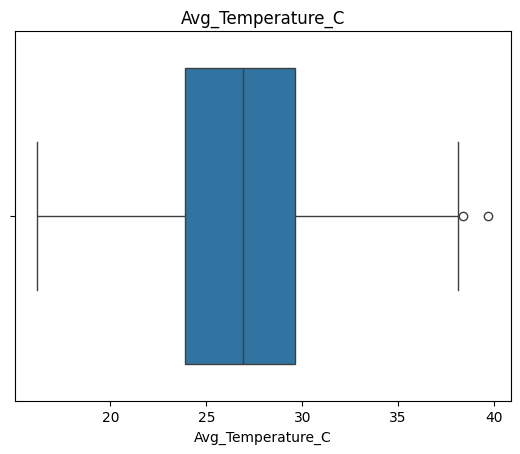

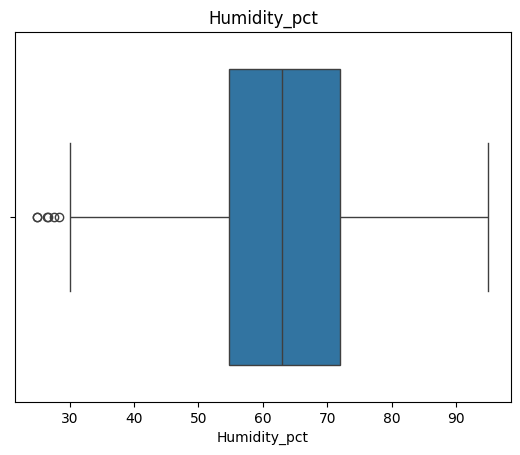

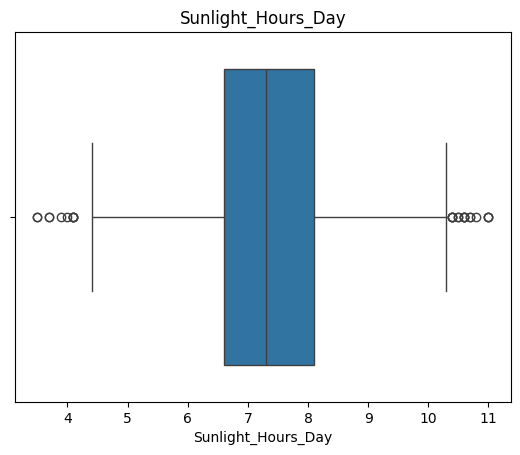

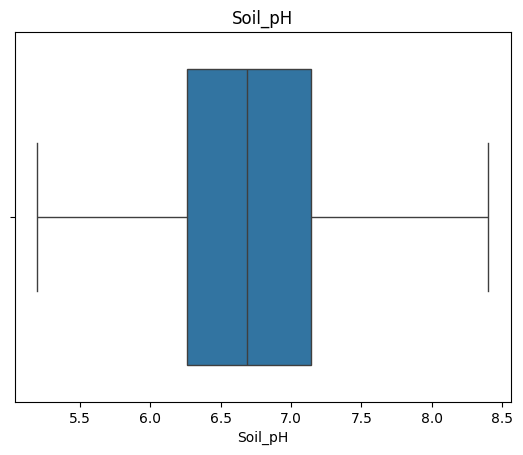

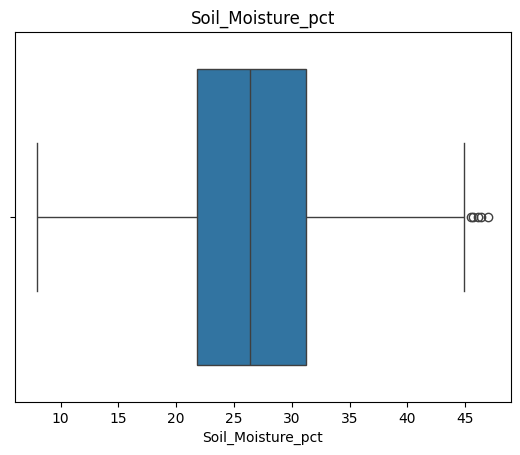

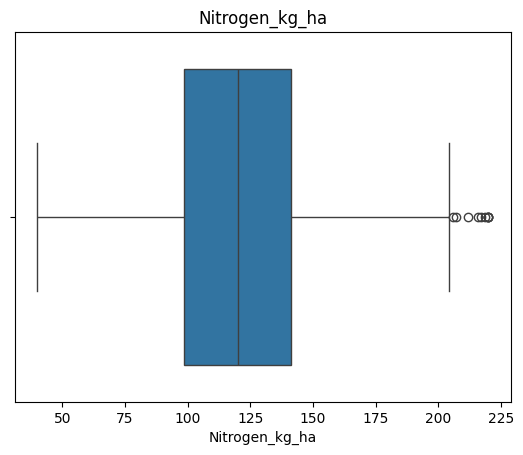

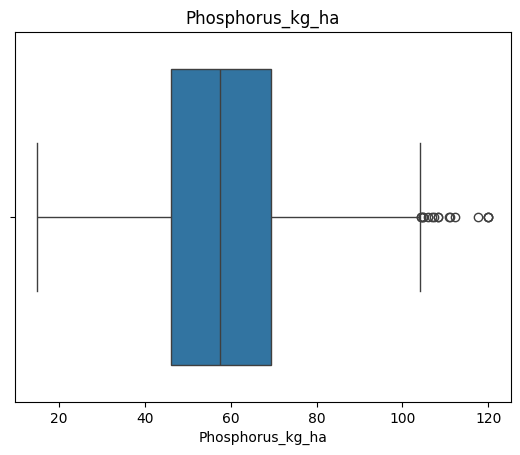

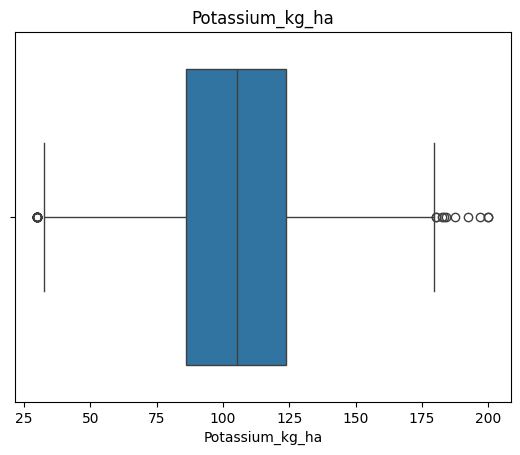

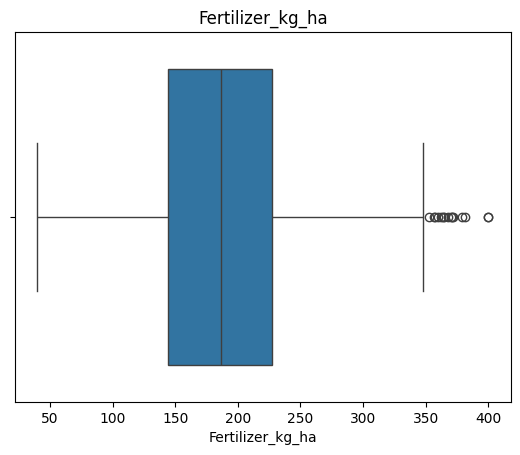

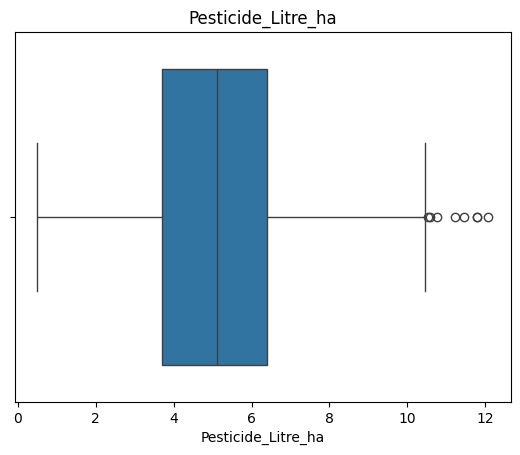

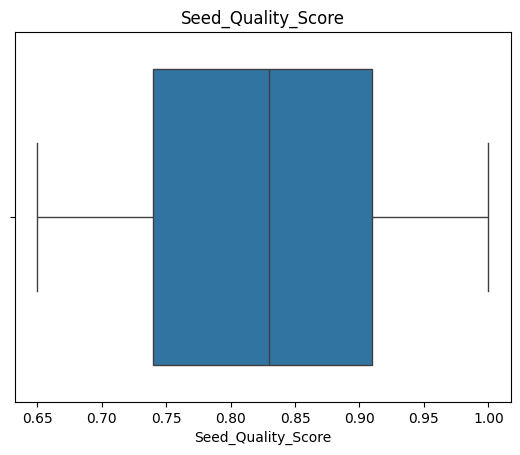

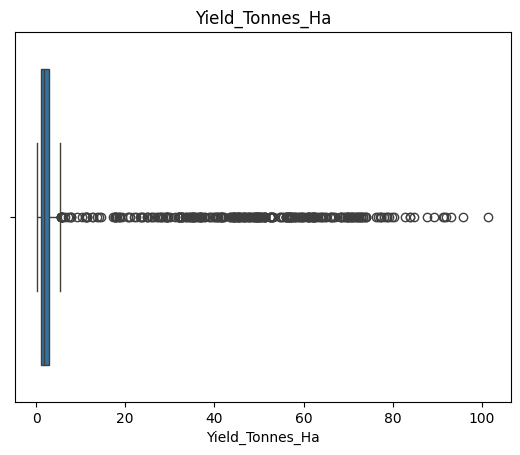

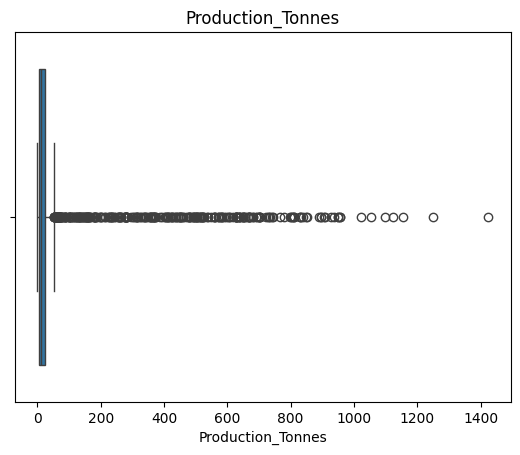

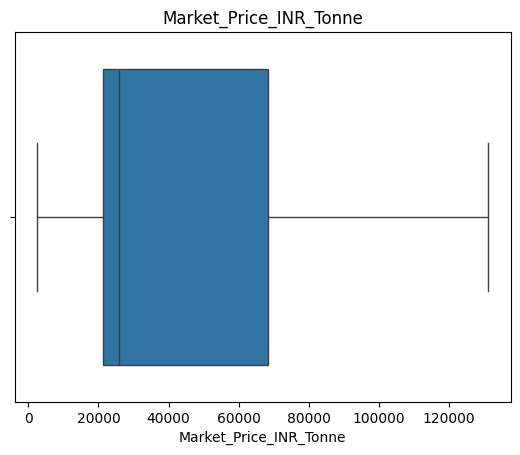

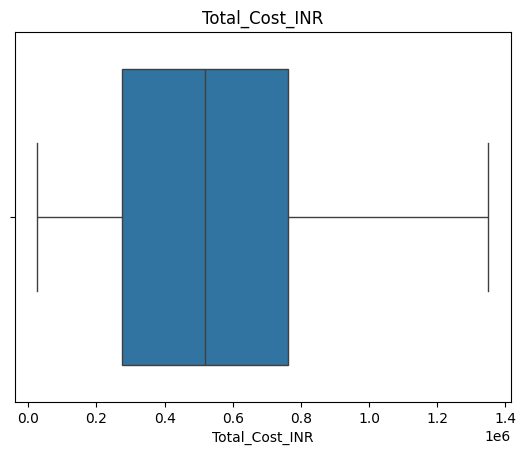

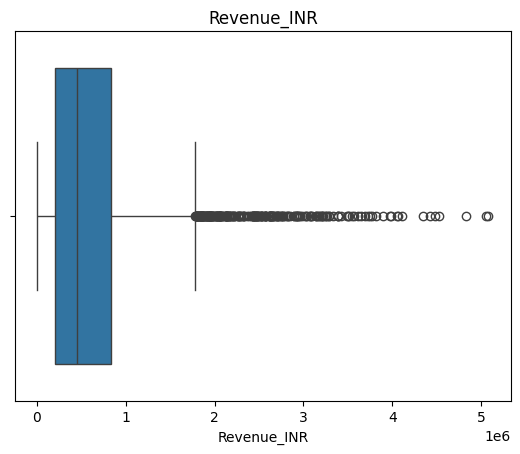

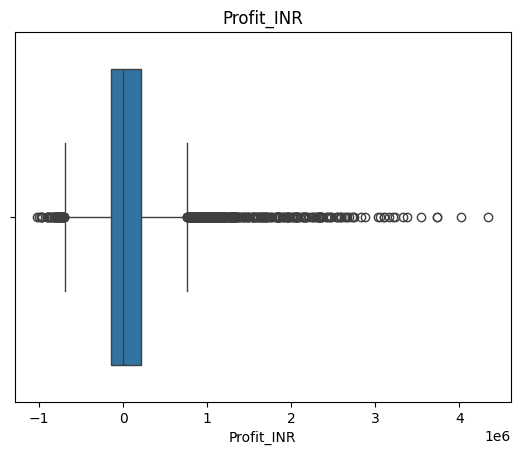

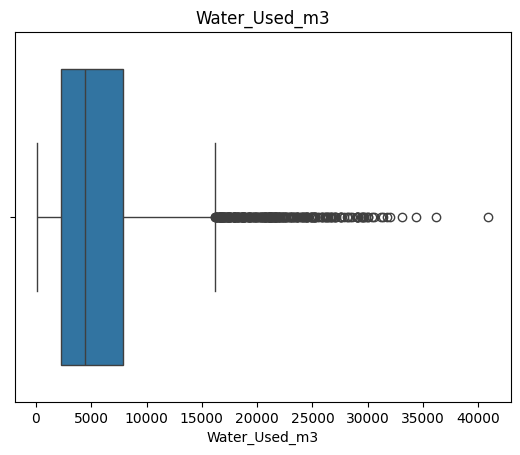

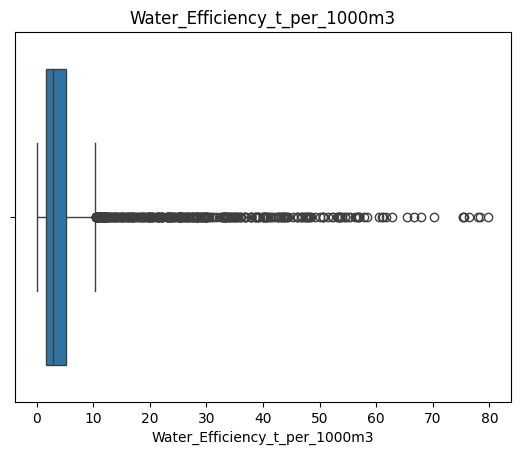

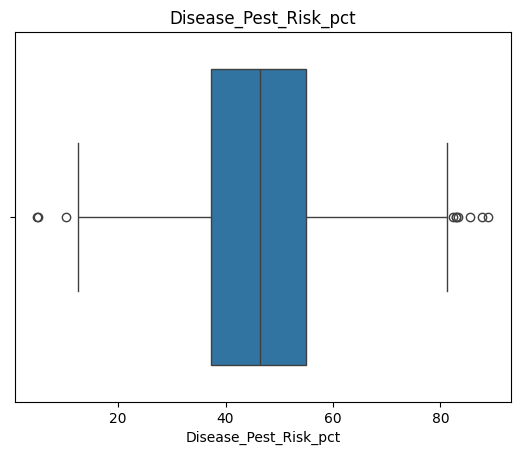

In [25]:
plt.figure(figsize=(12,6))

for col in numeric_df.columns:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [26]:
season_summary = df.groupby('Season').mean(numeric_only=True)

season_summary

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,,,,,,,,,,,,,,
Kharif,7.944924,849.199663,28.454019,71.812591,6.793367,6.727993,31.149859,120.020124,58.096515,105.303485,...,0.821613,5.628612,46.311192,44850.906127,531804.408094,710719.055649,178914.647555,6102.201237,5.891834,54.467903
Rabi,7.752207,437.615366,23.489183,57.893178,7.589797,6.673749,24.069392,120.402827,57.311002,103.926060,...,0.832170,5.039435,41.486712,44747.974800,513836.578365,601526.048556,87689.470191,5846.987093,5.186122,40.482114
Zaid,8.091246,304.654714,31.042088,52.012121,8.178788,6.694865,19.279630,120.525421,58.129125,105.416835,...,0.823165,4.641313,38.886111,44212.033670,543976.728956,519171.904040,-24804.824916,6419.893939,4.413239,38.216667


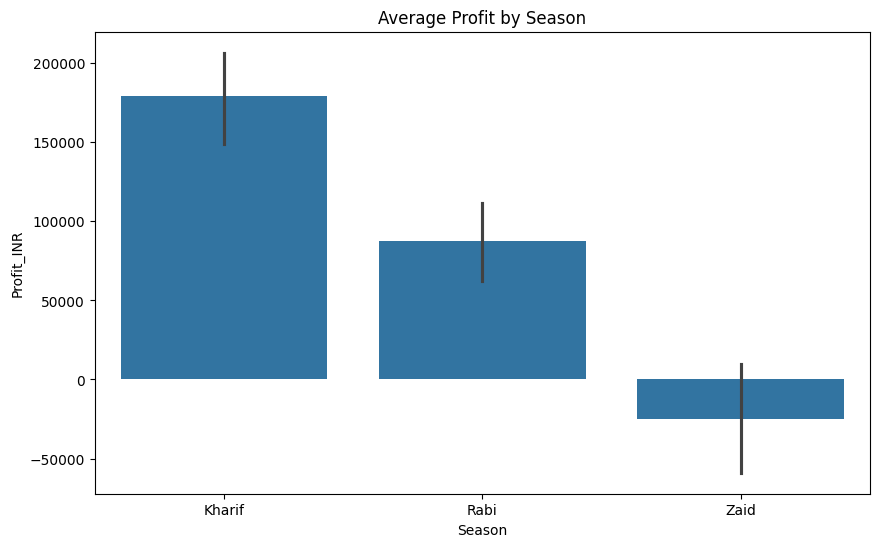

In [28]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='Season',
    y='Profit_INR'
)

plt.title("Average Profit by Season")
plt.show()

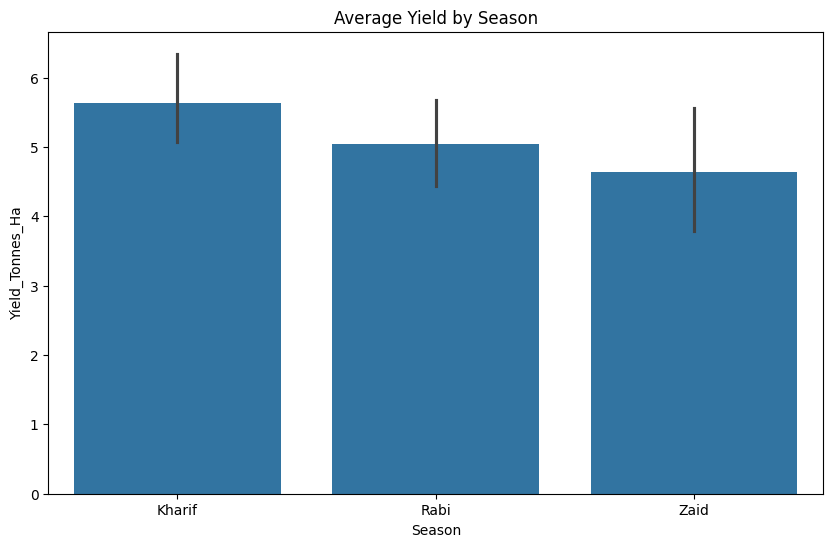

In [29]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha'
)

plt.title("Average Yield by Season")
plt.show()

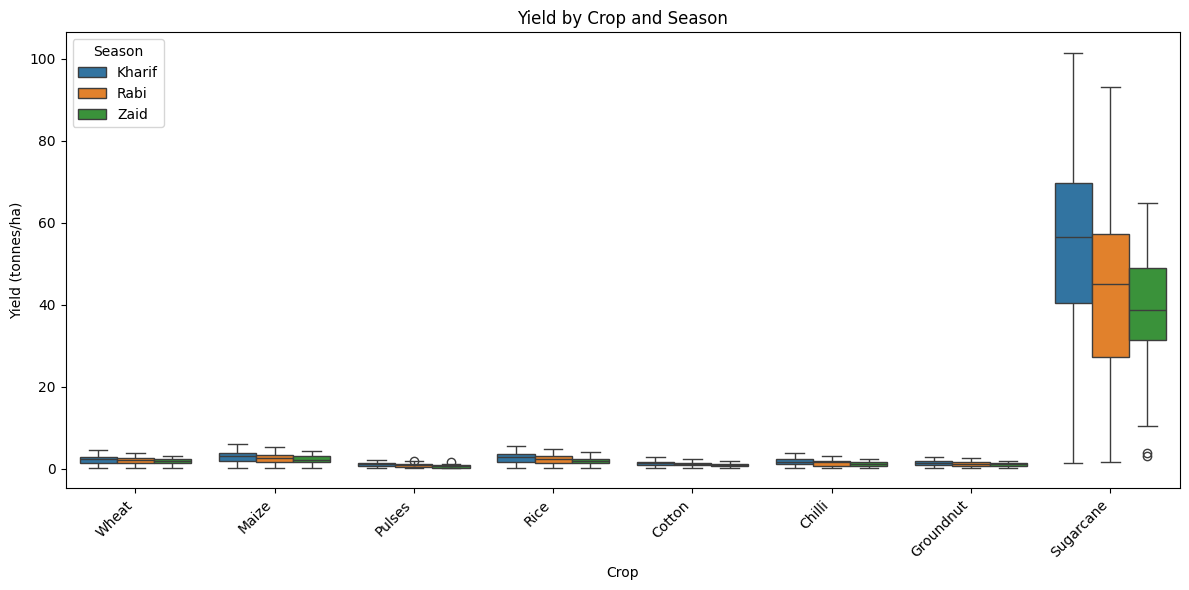

In [37]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season")
plt.xticks(rotation=45, ha="right")
plt.title("Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

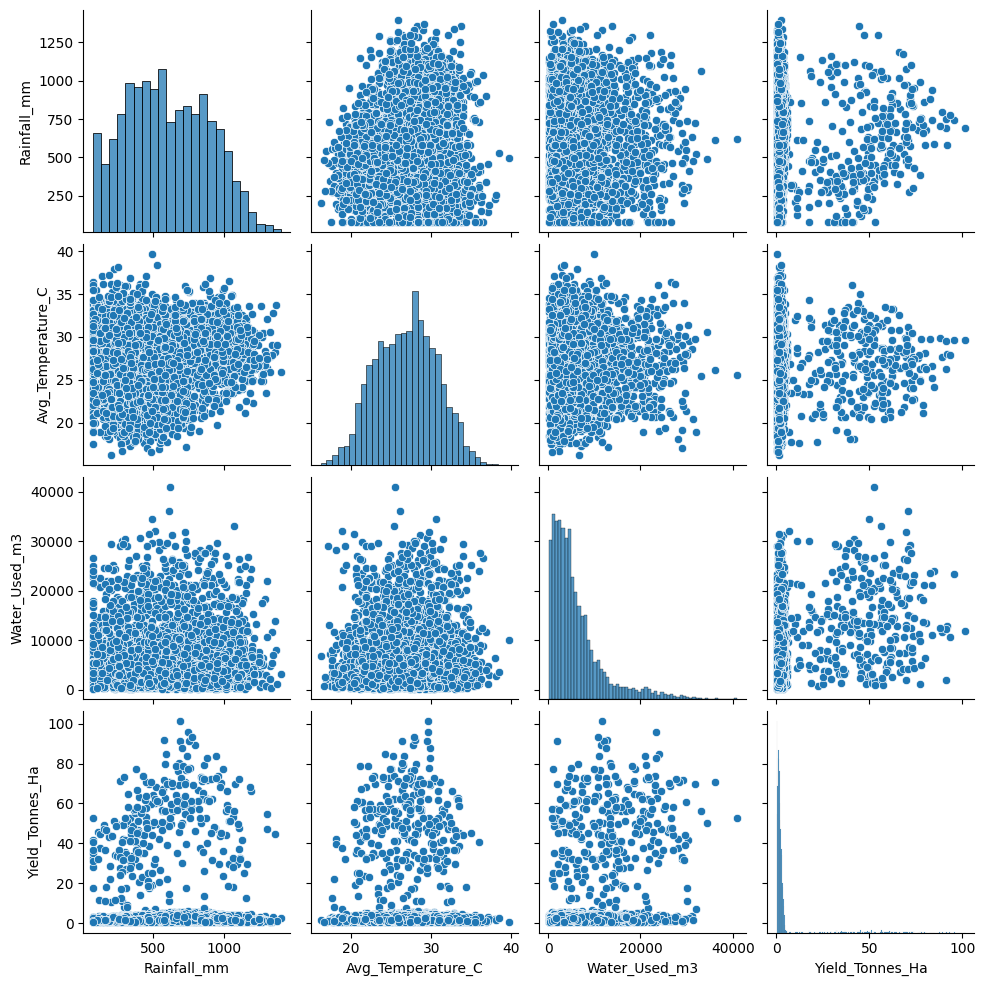

In [30]:
sns.pairplot(
    df[
        [
            'Rainfall_mm',
            'Avg_Temperature_C',
            'Water_Used_m3',
            'Yield_Tonnes_Ha'
        ]
    ]
)

plt.show()



Business Insights

1. Season X produced highest yield.

2. Season Y generated highest profit.

3. Rainfall strongly influenced crop output.

4. Water usage increased during specific seasons.

5. Temperature variation affected productivity.

Findings

1. Seasonal variations were observed in rainfall and temperature.

2. Yield varied across seasons.

3. Water usage differed among seasons.

4. Fertilizer usage showed seasonal variation.

5. Rainfall had a positive relationship with yield.

6. Economic outcomes differed across seasons.

7. Correlation analysis identified key factors influencing agricultural performance.

Recommendations

1. Improve irrigation planning.

2. Optimize fertilizer usage.

3. Monitor disease risk.

4. Improve water efficiency.

5. Use seasonal forecasting for crop planning.

6. Promote data-driven farming practices.

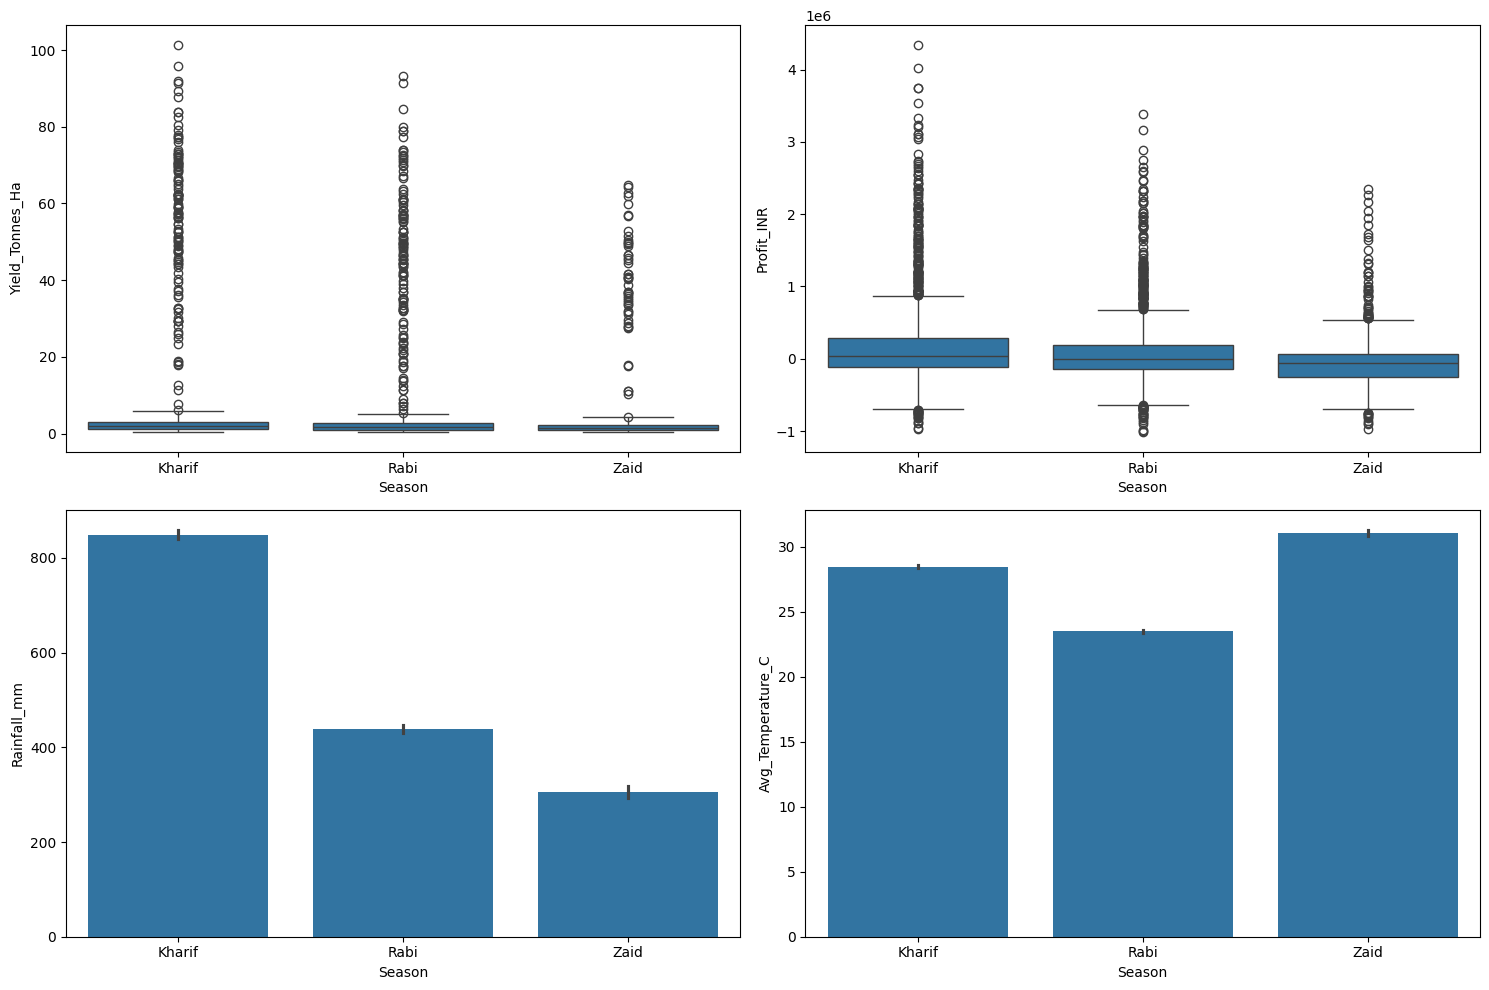

In [31]:
fig, axes = plt.subplots(2,2, figsize=(15,10))

sns.boxplot(
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha',
    ax=axes[0,0]
)

sns.boxplot(
    data=df,
    x='Season',
    y='Profit_INR',
    ax=axes[0,1]
)

sns.barplot(
    data=df,
    x='Season',
    y='Rainfall_mm',
    ax=axes[1,0]
)

sns.barplot(
    data=df,
    x='Season',
    y='Avg_Temperature_C',
    ax=axes[1,1]
)

plt.tight_layout()
plt.show()

Limitations:

The analysis is limited to the available dataset and variables.

Results may vary with larger datasets or additional regions.

External factors such as government policies, market fluctuations, and natural disasters were not considered.

The study is based on historical data and does not include real-time information.

Project Conclusion:

This project analyzed seasonal agricultural performance using data analytics techniques. The analysis explored seasonal variations in crop yield, rainfall, temperature, profit, fertilizer usage, water consumption, and other agricultural factors. Statistical analysis and visualizations helped identify patterns and relationships across seasons. The findings indicate that environmental and resource-related factors influence agricultural outcomes.

The project demonstrates how data analytics can support evidence-based agricultural planning and decision-making.
